# 📊 Lab Work - 1.3

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

# 🔹 Q1: Basic EDA

In [2]:
# Load Titanic dataset
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Shape and info
print("Shape:", df.shape)
df.info()

Shape: (891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
# Missing values
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
# Descriptive statistics
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# Summary table (mean, median, mode)
summary = pd.DataFrame({
    'Mean': df.mean(numeric_only=True),
    'Median': df.median(numeric_only=True),
    'Mode': df.mode(numeric_only=True).iloc[0]
})
summary

,Mean,Median,Mode
survived,0.383838,0.0000,0
pclass,2.308642,3.0000,3
age,29.699118,28.0000,24.0
sibsp,0.523008,0.0000,0
parch,0.381594,0.0000,0
fare,32.204208,14.4542,8.05
adult_male,0.602694,1.0000,True
alone,0.602694,1.0000,True


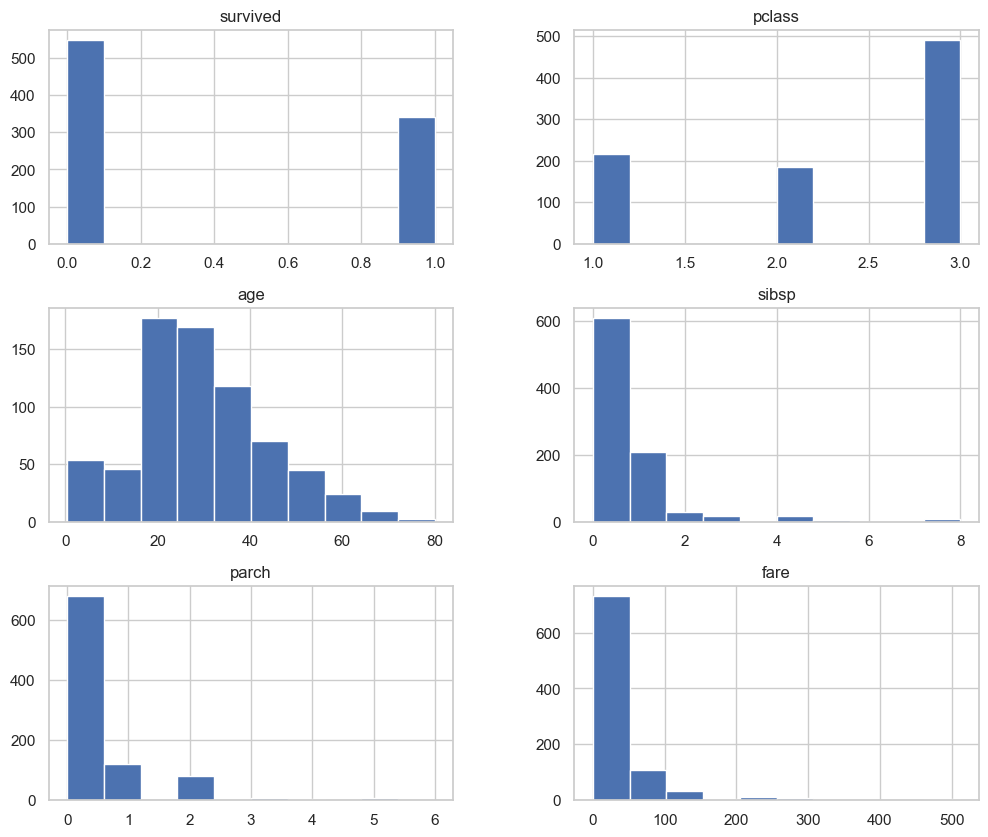

In [7]:
# Histograms
df.hist(figsize=(12,10))
plt.show()

# 🔹 Q2: Univariate Analysis

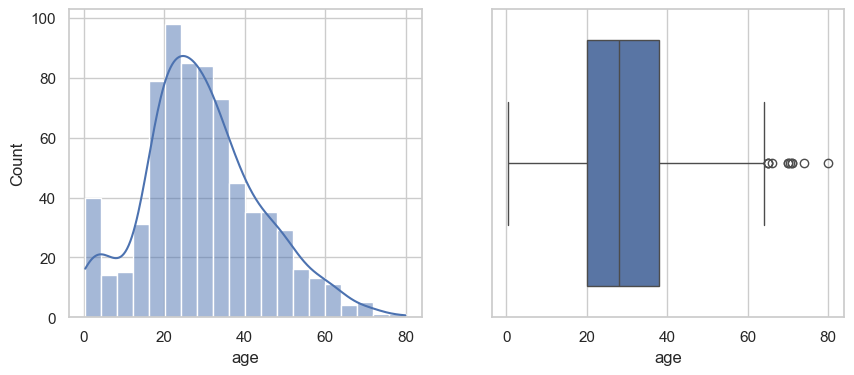

In [8]:
# Numeric column (Age)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['age'].dropna(), kde=True)

plt.subplot(1,2,2)
sns.boxplot(x=df['age'])
plt.show()

In [9]:
# Skewness and kurtosis
print("Skewness:", df['age'].skew())
print("Kurtosis:", df['age'].kurt())

Skewness: 0.38910778230082704
Kurtosis: 0.17827415364210353


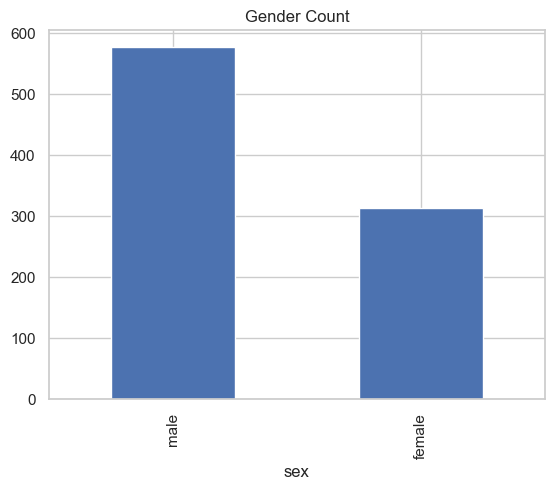

In [10]:
# Categorical column (Sex)
df['sex'].value_counts().plot(kind='bar')
plt.title("Gender Count")
plt.show()

# 🔹 Q3: Bivariate Analysis

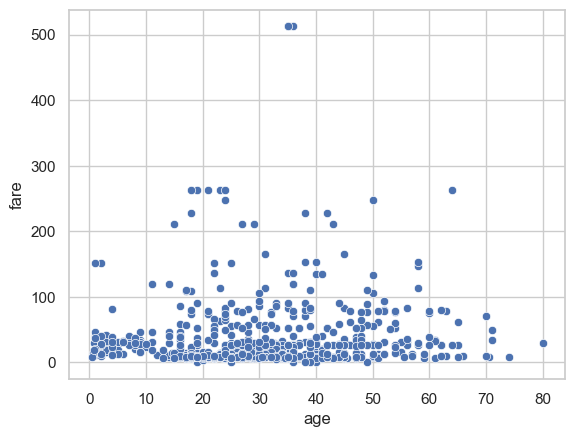

In [11]:
# Scatter plot (Age vs Fare)
sns.scatterplot(data=df, x='age', y='fare')
plt.show()

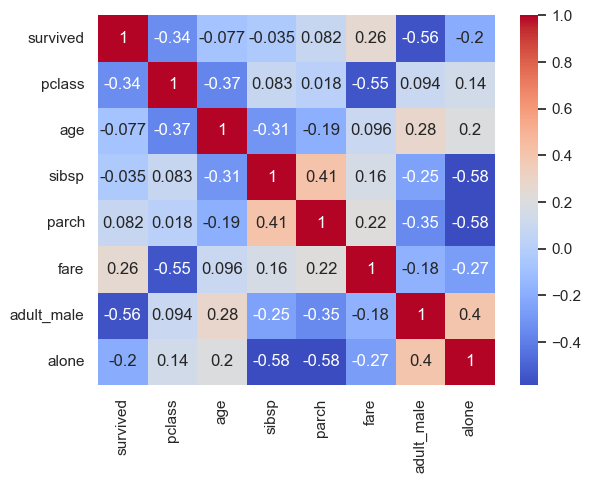

In [12]:
# Correlation heatmap
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

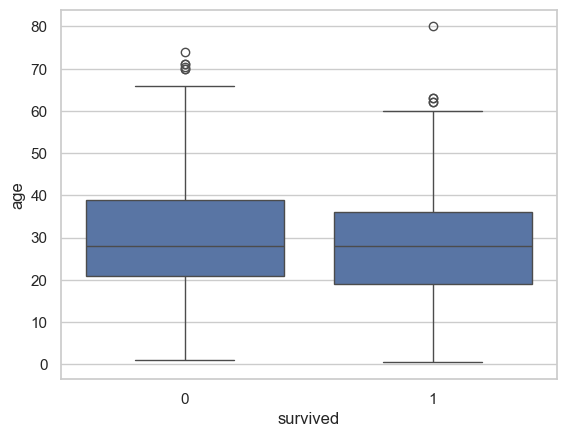

In [13]:
# Boxplot (Age vs Survival)
sns.boxplot(data=df, x='survived', y='age')
plt.show()

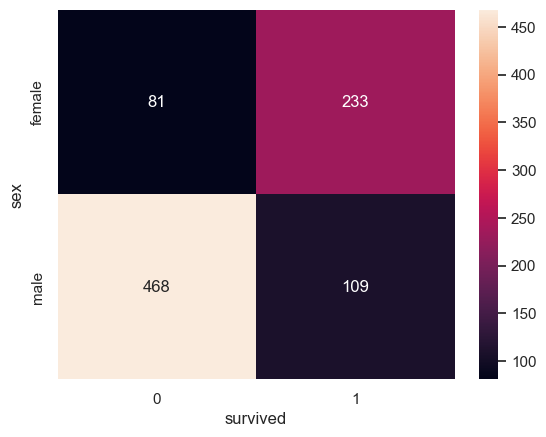

In [14]:
# Cross-tab (Gender vs Survival)
ct = pd.crosstab(df['sex'], df['survived'])
sns.heatmap(ct, annot=True, fmt='d')
plt.show()

# 🔹 Q4: Multivariate Analysis

In [15]:
# Load Iris dataset
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


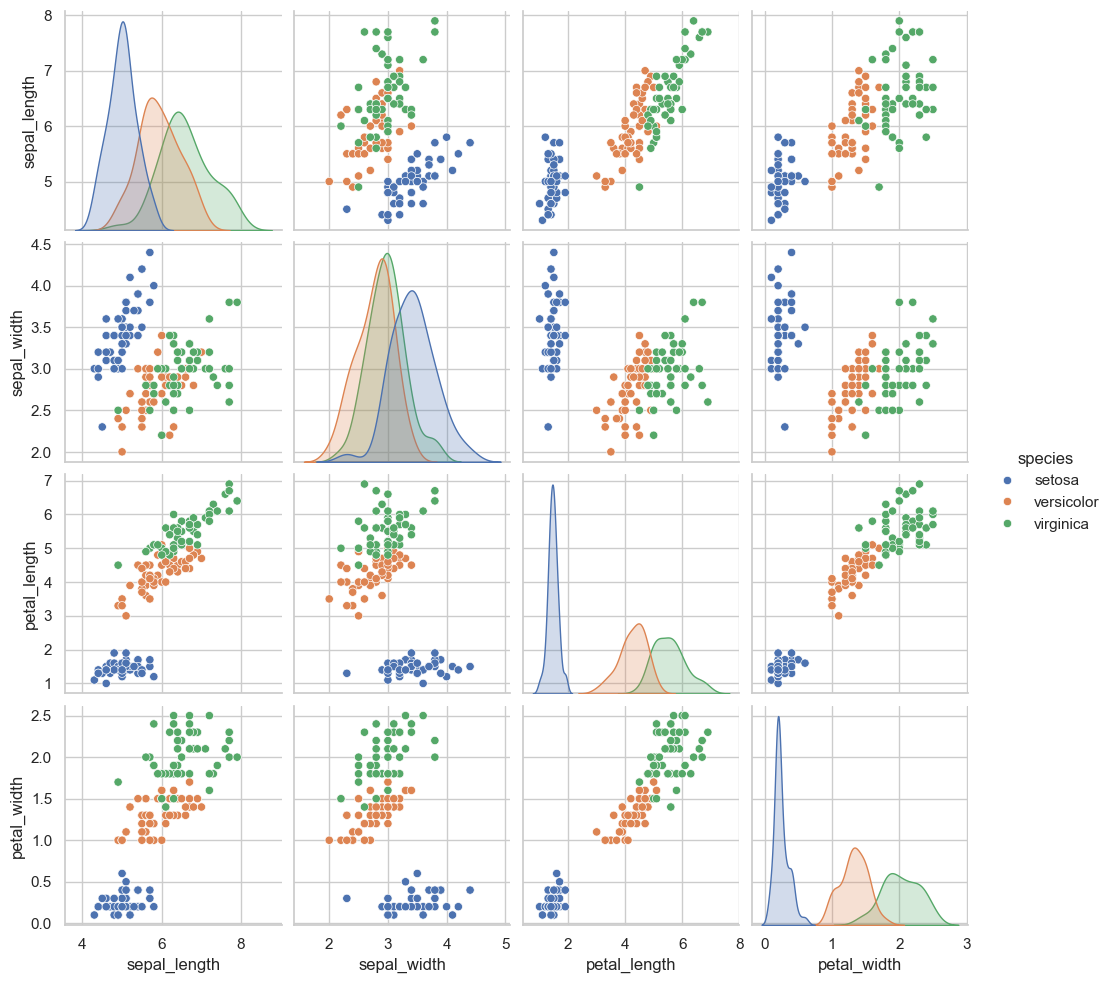

In [16]:
# Pairplot
sns.pairplot(iris, hue='species')
plt.show()

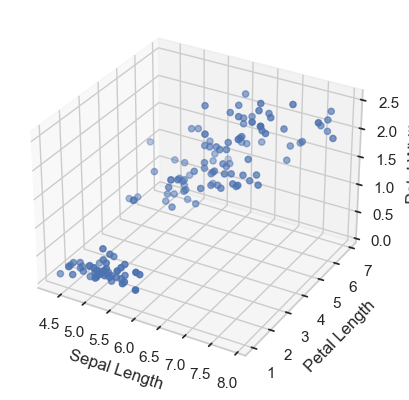

In [17]:
# 3D Scatter plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(iris['sepal_length'], iris['petal_length'], iris['petal_width'])
ax.set_xlabel('Sepal Length')
ax.set_ylabel('Petal Length')
ax.set_zlabel('Petal Width')

plt.show()

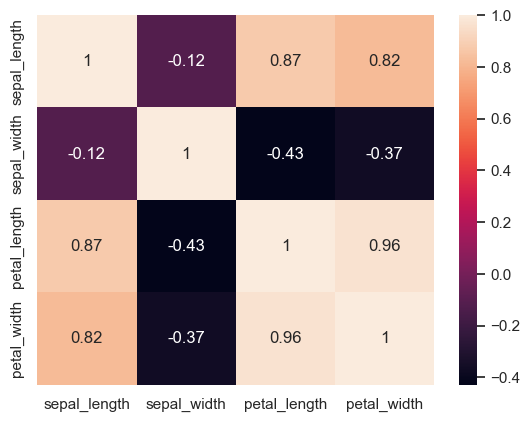

In [18]:
# Correlation heatmap
sns.heatmap(iris.corr(numeric_only=True), annot=True)
plt.show()

# 🔹 Q5: Pandas Profiling

In [19]:
# Install if needed
%pip install ydata-profiling

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -------------------------------- ------- 6.6/8.0 MB 33.5 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 26.1 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 26.4 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   - -------------------------------------- 1.0/38.1 MB ? eta -:--:--
   ---- ----------------------------------- 4.2/38.1 MB 13.2 MB/s eta 0:00:03
   ------ --------------------------------- 6.3/38.1 MB 11.0 MB/s eta 0:00:03
   ----------- ---------------------------- 11.0/38.1 MB 12.7 MB/s eta 0:00:03
   --------------- ------------------------ 14.7/38.1 MB 15.1 MB/s eta 0:00:02
   ------------------- -------------------- 18.9/38.1 MB 15.7 MB/s eta 0:00:02
   ------------------------- -------------- 24.6/38.1 MB 16.3 MB/s eta 0:00:01
   ----------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [20]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Titanic Dataset EDA Report", explorative=True)
profile.to_file("titanic_eda.html")

c:\Users\Dell\AppData\Local\Python\pythoncore-3.10-64\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Export report to file: 100%|██████████| 1/1 [00:00<00:00, 37.51it/s]
